# 04 — CatBoost Results

Présentation des résultats CatBoost : feature sweep (16 paliers) + Optuna (80 trials).

**Résultats clés** :
- FR : RMSE = **25.29** with 30 features (Optuna tuné)
- UK : RMSE = **10.66** with 100 features (Optuna tuné)
- Combined : **(25.29 + 10.66) / 2 = 17.98**

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Load all pre-computed results
with open('../outputs/catboost_sweep_results.json') as f:
    sweep = pd.DataFrame(json.load(f))

with open('../outputs/catboost_optuna_results.json') as f:
    optuna = json.load(f)

preds = np.load('../outputs/predictions/catboost_val_preds.npz', allow_pickle=True)

print('Data loaded. Sweep:', len(sweep), 'runs | Optuna: FR + UK done')

Data loaded. Sweep: 32 runs | Optuna: FR + UK done


---
## 1. Feature Sweep — RMSE vs nombre de features

On a testé CatBoost (params par défaut) with 16 paliers de features (10 à 377), classées par SHAP importance.

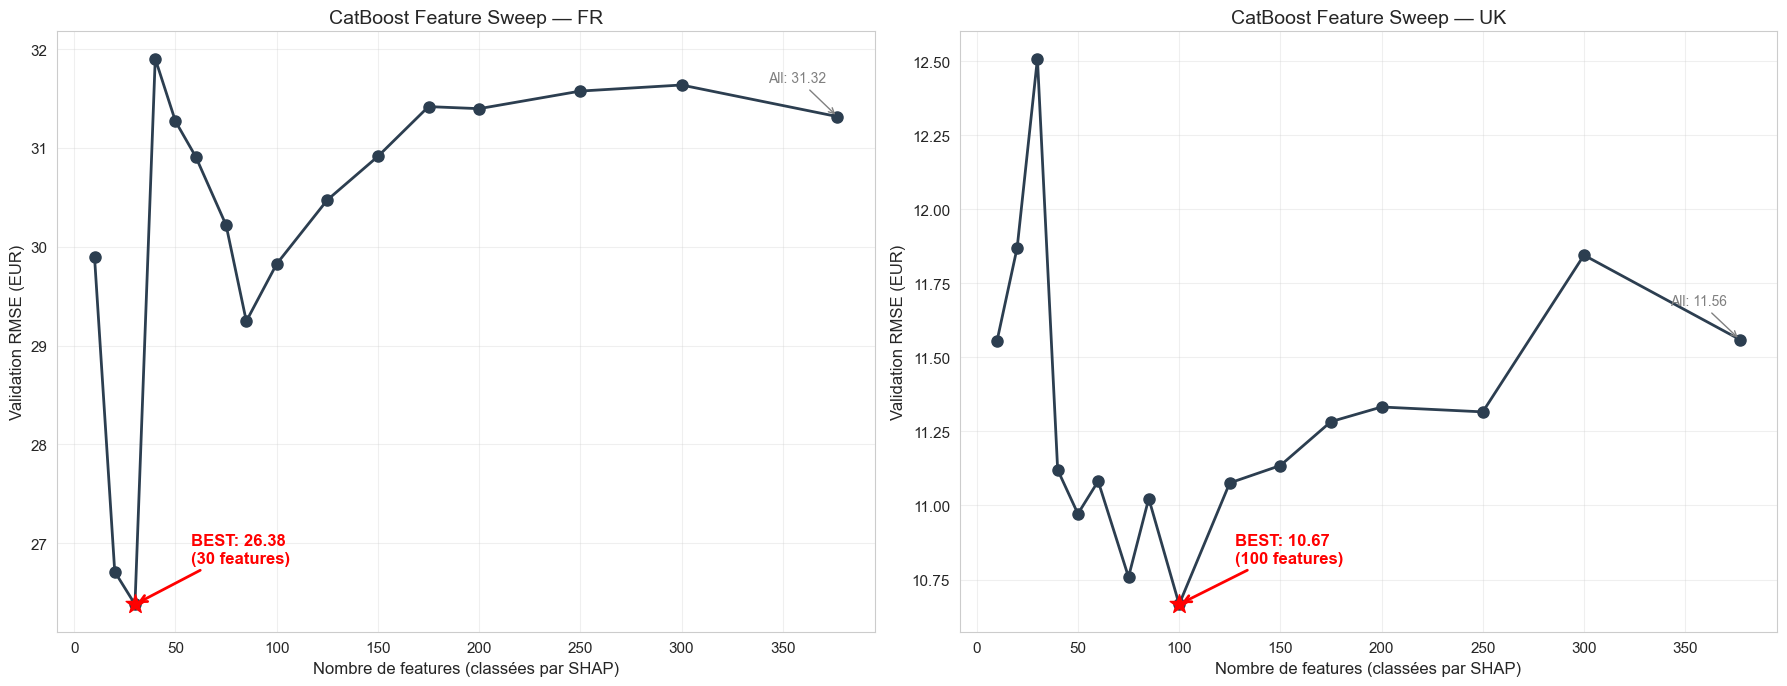

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, target, label, color in [
    (axes[0], 'fr_spot', 'FR', '#2c3e50'),
    (axes[1], 'uk_spot', 'UK', '#2c3e50'),
]:
    sub = sweep[sweep['target'] == target].sort_values('n_features')
    
    ax.plot(sub['n_features'], sub['rmse'], 'o-', color=color, linewidth=2, markersize=8)
    
    # Mark best
    best = sub.loc[sub['rmse'].idxmin()]
    ax.scatter([best['n_features']], [best['rmse']], color='red', s=200, zorder=5, marker='*')
    ax.annotate(f"BEST: {best['rmse']:.2f}\n({int(best['n_features'])} features)",
                xy=(best['n_features'], best['rmse']),
                xytext=(40, 30), textcoords='offset points',
                fontsize=12, fontweight='bold', color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    
    # Mark 377 (all features)
    all_feat = sub[sub['n_features'] == sub['n_features'].max()].iloc[0]
    ax.annotate(f"All: {all_feat['rmse']:.2f}",
                xy=(all_feat['n_features'], all_feat['rmse']),
                xytext=(-50, 25), textcoords='offset points',
                fontsize=10, color='gray',
                arrowprops=dict(arrowstyle='->', color='gray'))
    
    ax.set_xlabel('Nombre de features (classées par SHAP)', fontsize=12)
    ax.set_ylabel('Validation RMSE (EUR)', fontsize=12)
    ax.set_title(f'CatBoost Feature Sweep — {label}', fontsize=14)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/catboost_feature_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# Detailed sweep table
print('FEATURE SWEEP — FULL RESULTS')
print('='*80)

for target, label in [('fr_spot', 'FR'), ('uk_spot', 'UK')]:
    sub = sweep[sweep['target'] == target].sort_values('n_features', ascending=False)
    best_rmse = sub['rmse'].min()
    
    print(f'\n  {label}:')
    print(f"  {'Features':>10s}  {'RMSE':>8s}  {'MAE':>8s}  {'sMAPE':>8s}  {'Iters':>6s}  {'Time':>6s}  {'vs Best':>8s}")
    print(f"  {'-'*66}")
    for _, row in sub.iterrows():
        delta = row['rmse'] - best_rmse
        marker = ' ★' if delta == 0 else ''
        print(f"  {int(row['n_features']):>10d}  {row['rmse']:>8.3f}  {row['mae']:>8.3f}  "
              f"{row['smape']:>7.1f}%  {int(row['best_iter']):>6d}  {row['time_s']:>5.1f}s  "
              f"+{delta:.3f}{marker}")

FEATURE SWEEP — FULL RESULTS

  FR:
    Features      RMSE       MAE     sMAPE   Iters    Time   vs Best
  ------------------------------------------------------------------
         377    31.317    24.993     70.7%    2343   55.3s  +4.938
         300    31.637    25.263     70.8%    1948   42.6s  +5.257
         250    31.576    25.149     71.0%    1773   33.1s  +5.196
         200    31.398    25.316     71.1%     708   11.4s  +5.018
         175    31.418    25.130     71.1%    1543   20.6s  +5.039
         150    30.914    24.822     70.3%    1195   14.0s  +4.535
         125    30.473    24.226     69.8%     997   10.3s  +4.093
         100    29.826    23.844     69.6%    1233   10.2s  +3.446
          85    29.246    22.709     68.2%    1090    7.9s  +2.866
          75    30.219    23.825     69.7%    2163   13.7s  +3.839
          60    30.912    24.419     70.8%    1283    7.0s  +4.532
          50    31.269    24.654     71.6%     727    3.6s  +4.890
          40    31.904

### Analyse du sweep

**FR** : Deux vallées distinctes :
- Vallée 1 : **30 features** (26.38) — the model se concbetween on les ~30 features à fort signal
- Vallée 2 : **85 features** (29.25) — un second minimum plus large
- Avec 377 features : 31.32 — le bruit des 327 features faibles dégrade la performance

**UK** : Plateau between 50-150, optimum à **100 features** (10.67). UK a besoin de plus de features car les signaux sont distribués (wind, interconnectors, diversité de drivers).

**Conclusion** : SHAP avait raison — the features de bruit dégradent activement the model. Moins de features = meilleur RMSE.

---
## 2. Optuna — Hyperparamètres optimisés

In [4]:
# Optuna results comparison
print('OPTUNA RESULTS')
print('='*70)

for target, label in [('fr_spot', 'FR'), ('uk_spot', 'UK')]:
    r = optuna[target]
    
    # Find sweep baseline for same feature count
    n_feat = r['n_features']
    baseline = sweep[(sweep['target'] == target) & (sweep['n_features'] == n_feat)]
    baseline_rmse = baseline['rmse'].values[0] if len(baseline) > 0 else None
    
    print(f'\n  {label} ({n_feat} features):')
    print(f'    Default params RMSE:  {baseline_rmse:.3f}' if baseline_rmse else '    Default params: N/A')
    print(f'    Optuna RMSE:         {r["rmse"]:.3f}')
    if baseline_rmse:
        improvement = baseline_rmse - r['rmse']
        print(f'    Improvement:         {improvement:+.3f} ({improvement/baseline_rmse*100:.1f}%)')
    print(f'    MAE:                 {r["mae"]:.3f}')
    print(f'    sMAPE:               {r["smape"]:.1f}%')
    print(f'    Best iteration:      {r["best_iter"]}')
    print(f'    Optuna time:         {r["optuna_time_min"]} min')

print(f'\n  Combined RMSE = ({optuna["fr_spot"]["rmse"]:.3f} + {optuna["uk_spot"]["rmse"]:.3f}) / 2 = '
      f'{optuna["combined_rmse"]:.3f}')

OPTUNA RESULTS

  FR (30 features):
    Default params RMSE:  26.380
    Optuna RMSE:         25.290
    Improvement:         +1.089 (4.1%)
    MAE:                 19.107
    sMAPE:               63.4%
    Best iteration:      1015
    Optuna time:         6.6 min

  UK (100 features):
    Default params RMSE:  10.666
    Optuna RMSE:         10.664
    Improvement:         +0.002 (0.0%)
    MAE:                 7.885
    sMAPE:               17.5%
    Best iteration:      1348
    Optuna time:         18.6 min

  Combined RMSE = (25.290 + 10.664) / 2 = 17.977


In [5]:
# Best hyperparameters side by side
print('BEST HYPERPARAMETERS')
print('='*60)
print(f'{"Parameter":<25s} {"FR":>15s} {"UK":>15s}')
print(f'{"-"*55}')

all_params = set(list(optuna['fr_spot']['best_params'].keys()) + 
                 list(optuna['uk_spot']['best_params'].keys()))

for param in sorted(all_params):
    fr_val = optuna['fr_spot']['best_params'].get(param, '-')
    uk_val = optuna['uk_spot']['best_params'].get(param, '-')
    if isinstance(fr_val, float):
        print(f'{param:<25s} {fr_val:>15.4f} {uk_val:>15.4f}')
    else:
        print(f'{param:<25s} {str(fr_val):>15s} {str(uk_val):>15s}')

print(f'\nFeatures used:            {optuna["fr_spot"]["n_features"]:>15d} {optuna["uk_spot"]["n_features"]:>15d}')

BEST HYPERPARAMETERS
Parameter                              FR              UK
-------------------------------------------------------
bagging_temperature                0.4446          0.2402
depth                                   9               7
l2_leaf_reg                        1.6556          6.5149
learning_rate                      0.0698          0.0393
min_data_in_leaf                       76               9
random_strength                    1.5102          1.3547
subsample                          0.6384          0.8253

Features used:                         30             100


---
## 3. Feature Importance — CatBoost (Optuna model)

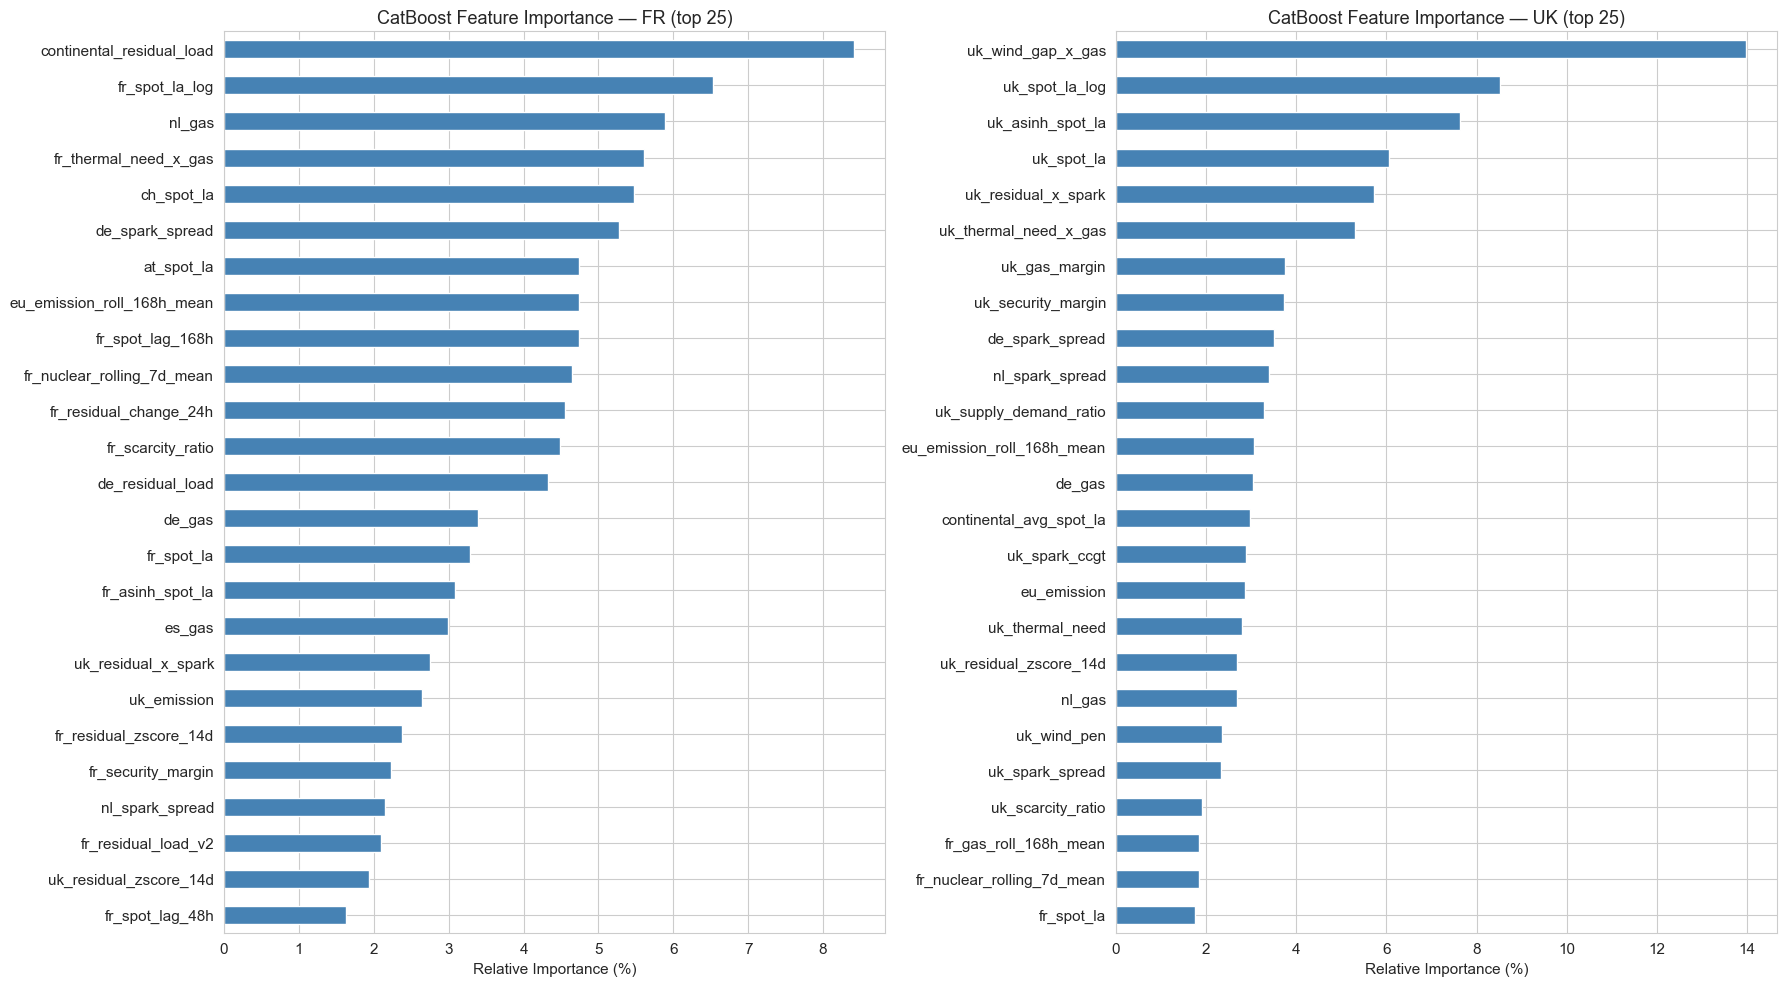

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for ax, target, label in [
    (axes[0], 'fr_spot', 'FR'),
    (axes[1], 'uk_spot', 'UK'),
]:
    imp = pd.Series(optuna[target]['feature_importances']).sort_values(ascending=False)
    top25 = imp.head(25)
    top25_norm = top25 / top25.sum() * 100
    
    top25_norm.iloc[::-1].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'CatBoost Feature Importance — {label} (top 25)', fontsize=13)
    ax.set_xlabel('Relative Importance (%)')

plt.tight_layout()
plt.savefig('../outputs/catboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Full feature importance tables
# Also load SHAP rankings for comparison
shap_fr = pd.read_csv('../outputs/shap_ranking_fr.csv', index_col=0).squeeze()
shap_uk = pd.read_csv('../outputs/shap_ranking_uk.csv', index_col=0).squeeze()

shap_ranks_fr = {feat: i+1 for i, feat in enumerate(shap_fr.index)}
shap_ranks_uk = {feat: i+1 for i, feat in enumerate(shap_uk.index)}

for target, label, shap_ranks in [
    ('fr_spot', 'FR', shap_ranks_fr),
    ('uk_spot', 'UK', shap_ranks_uk),
]:
    imp = pd.Series(optuna[target]['feature_importances']).sort_values(ascending=False)
    
    print(f'\n{"="*70}')
    print(f'  {label} — CatBoost Feature Importance (all {len(imp)} features)')
    print(f'{"="*70}')
    print(f'{"Rank":>5s}  {"Feature":<42s} {"CB Imp":>8s} {"SHAP Rank":>10s}  {"Match?":>6s}')
    print(f'{"-"*75}')
    
    for i, (feat, val) in enumerate(imp.items()):
        shap_rank = shap_ranks.get(feat, '?')
        match = '✓' if isinstance(shap_rank, int) and abs((i+1) - shap_rank) < 10 else ' '
        print(f'{i+1:>5d}  {feat:<42s} {val:>8.2f} {str(shap_rank):>10s}  {match:>6s}')
        if i >= 29:  # Show top 30
            break


  FR — CatBoost Feature Importance (all 30 features)
 Rank  Feature                                      CB Imp  SHAP Rank  Match?
---------------------------------------------------------------------------
    1  continental_residual_load                      7.85          4       ✓
    2  fr_spot_la_log                                 6.10         14        
    3  nl_gas                                         5.49         10       ✓
    4  fr_thermal_need_x_gas                          5.24          5       ✓
    5  ch_spot_la                                     5.11          2       ✓
    6  de_spark_spread                                4.92          1       ✓
    7  at_spot_la                                     4.43          6       ✓
    8  eu_emission_roll_168h_mean                     4.43         24        
    9  fr_spot_lag_168h                               4.43          7       ✓
   10  fr_nuclear_rolling_7d_mean                     4.33         23        
   11  fr_re

---
## 4. RMSE par heure — Où the model galère ?

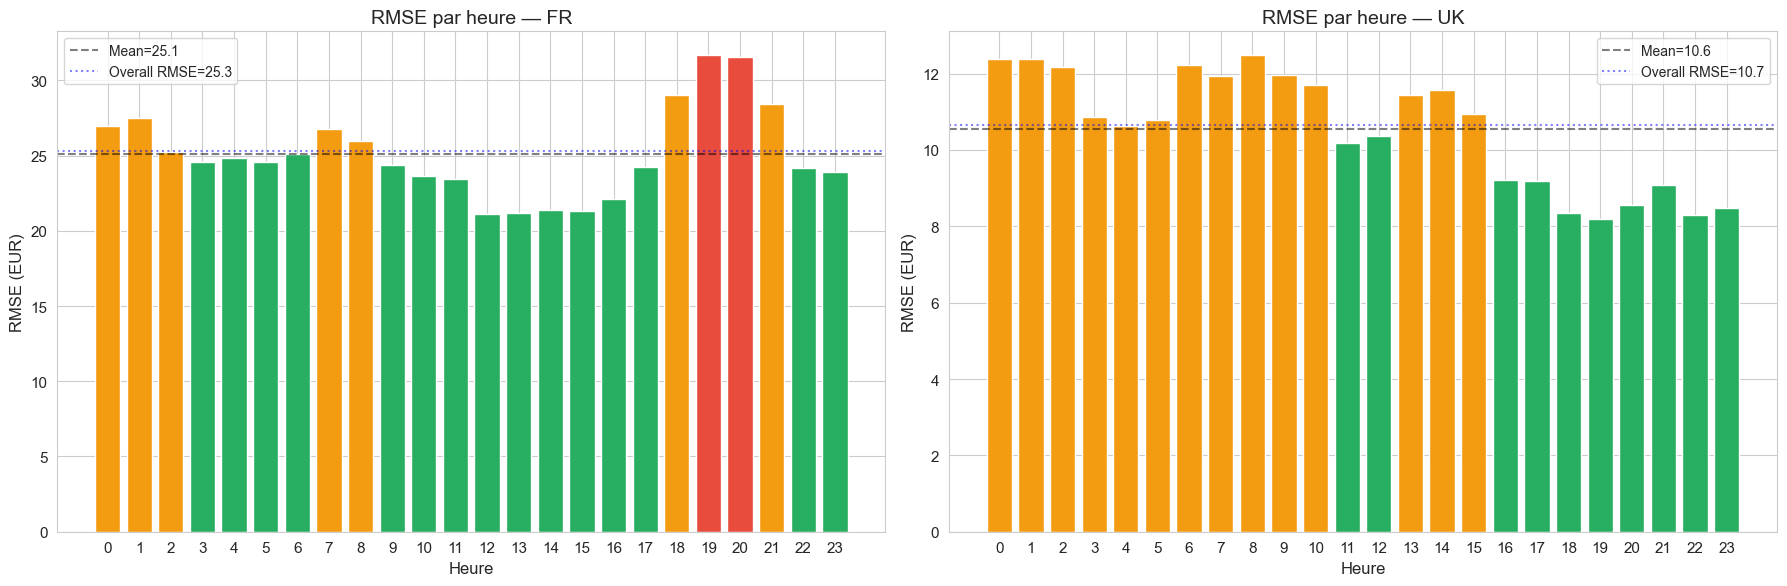

Rouge = heures difficiles (RMSE > 120% moyenne)
Vert = heures faciles | Orange = moyenne

FR worst hours:  h19=31.7, h20=31.5, h18=29.0, h21=28.4, h1=27.5

UK worst hours:  h8=12.5, h0=12.4, h1=12.4, h6=12.2, h2=12.2


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, target, label in [
    (axes[0], 'fr_spot', 'FR'),
    (axes[1], 'uk_spot', 'UK'),
]:
    hourly = optuna[target]['hourly_rmse']
    hours = [int(h) for h in sorted(hourly.keys(), key=int)]
    rmses = [hourly[str(h)] for h in hours]
    mean_rmse = np.mean(rmses)
    
    colors = ['#e74c3c' if r > mean_rmse * 1.2 else 
              '#f39c12' if r > mean_rmse else 
              '#27ae60' for r in rmses]
    
    bars = ax.bar(hours, rmses, color=colors)
    ax.axhline(mean_rmse, color='black', linestyle='--', alpha=0.5, 
               label=f'Mean={mean_rmse:.1f}')
    ax.axhline(optuna[target]['rmse'], color='blue', linestyle=':', alpha=0.5,
               label=f'Overall RMSE={optuna[target]["rmse"]:.1f}')
    
    ax.set_xlabel('Heure', fontsize=12)
    ax.set_ylabel('RMSE (EUR)', fontsize=12)
    ax.set_title(f'RMSE par heure — {label}', fontsize=14)
    ax.set_xticks(range(24))
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/catboost_rmse_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

print('Rouge = heures difficiles (RMSE > 120% moyenne)')
print('Vert = heures faciles | Orange = moyenne')

# Worst hours
for target, label in [('fr_spot', 'FR'), ('uk_spot', 'UK')]:
    hourly = optuna[target]['hourly_rmse']
    sorted_hours = sorted(hourly.items(), key=lambda x: x[1], reverse=True)
    print(f'\n{label} worst hours: ', 
          ', '.join(f'h{h}={v:.1f}' for h, v in sorted_hours[:5]))

---
## 5. Analyse des residuals

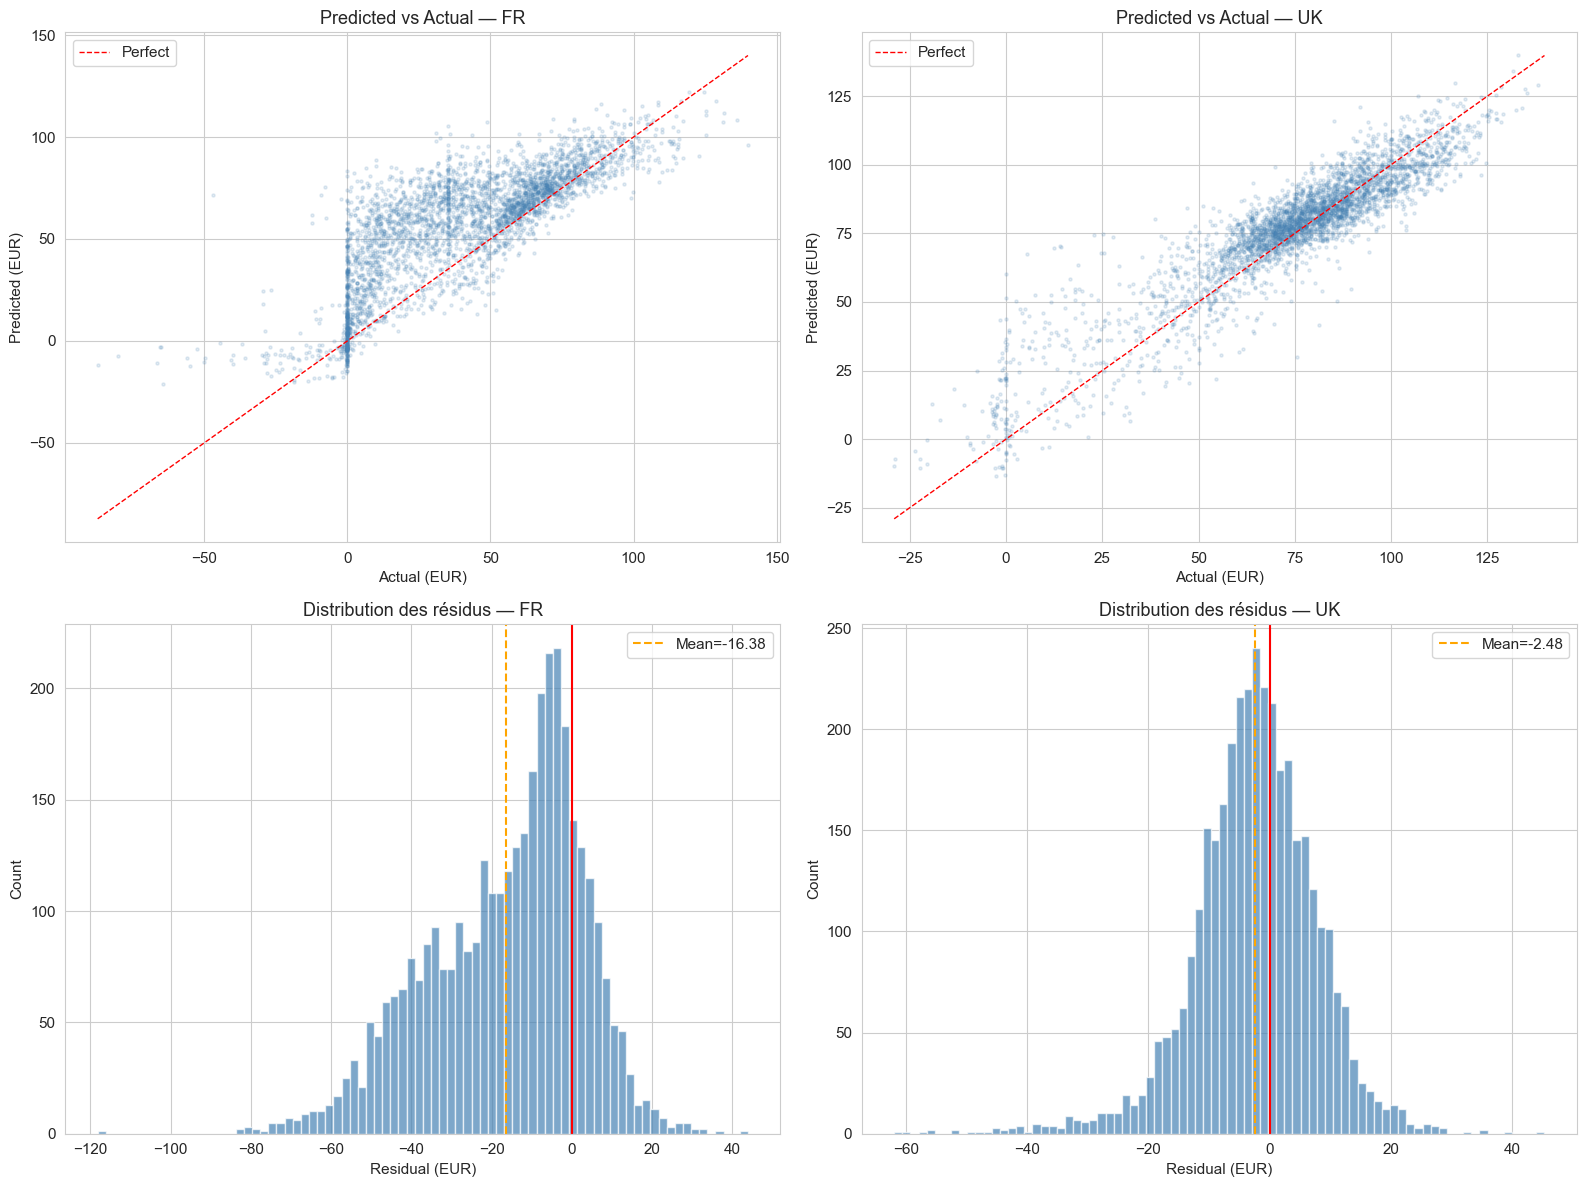

In [9]:
preds_fr = preds['preds_fr']
preds_uk = preds['preds_uk']
y_val_fr = preds['y_val_fr']
y_val_uk = preds['y_val_uk']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for col, (y_true, y_pred, label) in enumerate([
    (y_val_fr, preds_fr, 'FR'),
    (y_val_uk, preds_uk, 'UK'),
]):
    residuals = y_true - y_pred
    
    # Scatter: predicted vs actual
    ax = axes[0, col]
    ax.scatter(y_true, y_pred, alpha=0.15, s=5, c='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect')
    ax.set_xlabel('Actual (EUR)')
    ax.set_ylabel('Predicted (EUR)')
    ax.set_title(f'Predicted vs Actual — {label}', fontsize=13)
    ax.legend()
    
    # Residual distribution
    ax = axes[1, col]
    ax.hist(residuals, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', linewidth=1.5)
    ax.axvline(np.mean(residuals), color='orange', linewidth=1.5, linestyle='--',
               label=f'Mean={np.mean(residuals):.2f}')
    ax.set_xlabel('Residual (EUR)')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution des résidus — {label}', fontsize=13)
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/catboost_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Residual statistics
print('RESIDUAL ANALYSIS')
print('='*60)

for target, label in [('fr_spot', 'FR'), ('uk_spot', 'UK')]:
    r = optuna[target]
    print(f'\n  {label}:')
    print(f'    Mean bias:   {r["residuals_mean"]:+.3f} EUR')
    print(f'    Median bias: {r["residuals_median"]:+.3f} EUR')
    print(f'    Std:         {r["residuals_std"]:.3f} EUR')
    print(f'    Skewness:    {r["residuals_skew"]:+.3f}')
    
    if abs(r['residuals_mean']) < 1:
        print(f'    → Biais négligeable ✓')
    else:
        print(f'    → Biais significatif ⚠ (hourly bias correction recommandée)')
    
    if abs(r['residuals_skew']) > 1:
        print(f'    → Distribution asymétrique — résidus avec queue longue')
    else:
        print(f'    → Distribution relativement symétrique ✓')

RESIDUAL ANALYSIS

  FR:
    Mean bias:   -16.375 EUR
    Median bias: -12.365 EUR
    Std:         19.273 EUR
    Skewness:    -0.582
    → Biais significatif ⚠ (hourly bias correction recommandée)
    → Distribution relativement symétrique ✓

  UK:
    Mean bias:   -2.484 EUR
    Median bias: -2.124 EUR
    Std:         10.370 EUR
    Skewness:    -0.641
    → Biais significatif ⚠ (hourly bias correction recommandée)
    → Distribution relativement symétrique ✓


---
## 6. Time Series — Prédictions vs Réel

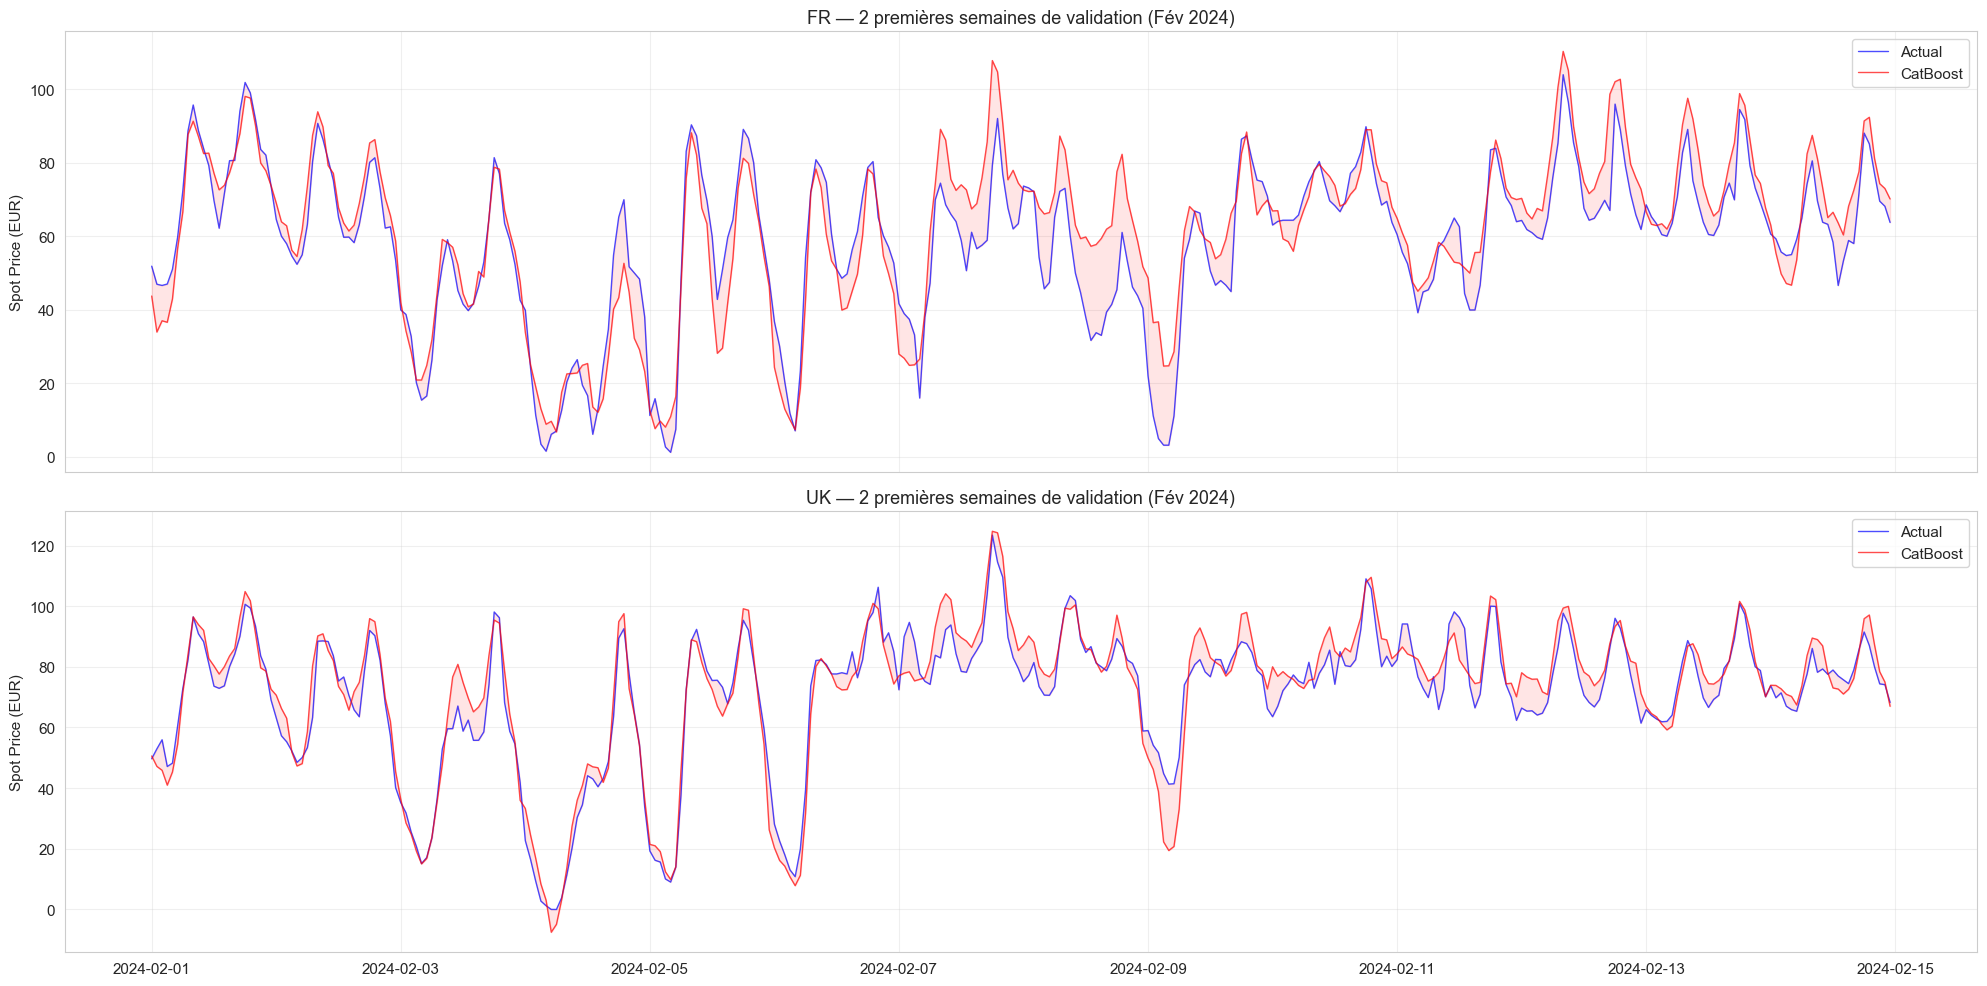

In [11]:
val_dates = pd.to_datetime(preds['val_dates'])

fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

n = 24 * 14  # 2 weeks

for ax, y_true, y_pred, label in [
    (axes[0], y_val_fr, preds_fr, 'FR'),
    (axes[1], y_val_uk, preds_uk, 'UK'),
]:
    ax.plot(val_dates[:n], y_true[:n], 'b-', alpha=0.7, linewidth=1, label='Actual')
    ax.plot(val_dates[:n], y_pred[:n], 'r-', alpha=0.7, linewidth=1, label='CatBoost')
    ax.fill_between(val_dates[:n], y_true[:n], y_pred[:n], alpha=0.1, color='red')
    ax.set_ylabel('Spot Price (EUR)')
    ax.set_title(f'{label} — 2 premières semaines de validation (Fév 2024)', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/catboost_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Worst predictions — where does the model fail?
for y_true, y_pred, label in [
    (y_val_fr, preds_fr, 'FR'),
    (y_val_uk, preds_uk, 'UK'),
]:
    residuals = np.abs(y_true - y_pred)
    worst_idx = np.argsort(residuals)[-10:][::-1]
    
    print(f'\n{label} — Top 10 worst predictions:')
    print(f'{"Date":>25s}  {"Actual":>8s}  {"Predicted":>10s}  {"Error":>8s}')
    print(f'{"-"*55}')
    for idx in worst_idx:
        date = str(val_dates[idx])[:16]
        print(f'{date:>25s}  {y_true[idx]:>8.1f}  {y_pred[idx]:>10.1f}  {residuals[idx]:>8.1f}')


FR — Top 10 worst predictions:
                     Date    Actual   Predicted     Error
-------------------------------------------------------
         2024-06-26 01:00     -46.8        71.3     118.2
         2024-06-26 00:00      -7.8        75.6      83.4
         2024-06-26 07:00       0.0        83.2      83.2
         2024-06-26 08:00      -0.1        80.8      80.9
         2024-06-26 02:00      -9.2        71.4      80.6
         2024-05-31 08:00       2.5        82.5      80.0
         2024-04-16 21:00      10.0        88.9      78.8
         2024-04-16 20:00       6.7        84.9      78.2
         2024-04-20 21:00      10.0        86.0      76.0
         2024-05-12 14:00     -87.3       -11.9      75.4

UK — Top 10 worst predictions:
                     Date    Actual   Predicted     Error
-------------------------------------------------------
         2024-06-08 09:00       5.5        67.5      62.0
         2024-06-08 10:00       0.0        60.3      60.3
         202

---
## 7. Features utilisées — Liste complète

In [13]:
for target, label in [('fr_spot', 'FR'), ('uk_spot', 'UK')]:
    feats = optuna[target]['features']
    print(f'\n{label} — {len(feats)} features utilisées:')
    for i, f in enumerate(feats):
        print(f'  {i+1:3d}. {f}')


FR — 30 features utilisées:
    1. de_spark_spread
    2. ch_spot_la
    3. fr_spot_la
    4. continental_residual_load
    5. fr_thermal_need_x_gas
    6. at_spot_la
    7. fr_spot_lag_168h
    8. de_residual_load
    9. nl_spark_spread
   10. nl_gas
   11. fr_thermal_need
   12. es_gas
   13. fr_asinh_spot_la
   14. fr_spot_la_log
   15. fr_residual_change_24h
   16. fr_scarcity_ratio
   17. fr_security_margin
   18. fr_spot_lag_48h
   19. de_gas
   20. uk_residual_x_spark
   21. fr_residual_zscore_14d
   22. fr_residual_ramp_3h
   23. fr_nuclear_rolling_7d_mean
   24. eu_emission_roll_168h_mean
   25. uk_emission
   26. es_spot_la
   27. uk_residual_ramp_3h
   28. uk_residual_zscore_14d
   29. fr_gas
   30. fr_residual_load_v2

UK — 100 features utilisées:
    1. uk_spot_la
    2. uk_residual_x_spark
    3. uk_wind_gap_x_gas
    4. uk_spot_la_log
    5. uk_thermal_need_x_gas
    6. uk_asinh_spot_la
    7. uk_wind_pen
    8. fr_spot_la
    9. uk_spot_lag_168h
   10. de_gas
   11. co

---
## 8. Synthèse

### CatBoost Results (Optuna tuné)

| Cible | RMSE | MAE | sMAPE | Features | Iterations |
|-------|------|-----|-------|----------|------------|
| FR | 25.29 | 19.11 | 63.4% | 30 | 1015 |
| UK | 10.66 | 7.89 | 17.5% | 100 | 1348 |
| **Combined** | **17.98** | | | | |

### Ce que le sweep nous apprend
- FR n'a besoin que de **30 features** — le marché est piloté par les spark spreads et les prix voisins
- UK a besoin de **100 features** — marché plus complexe (wind, interconnectors, multiples drivers)
- Ajouter des features de bruit **dégrade** activement la performance (377 feat = +5 RMSE for FR)

### Prochaines étapes
1. **LightGBM** with loss MAE → diversité d'erreurs for l'ensemble
2. **Ensemble** Ridge (CatBoost + LightGBM) → devrait battre chaque modèle seul
3. **Post-processing** : clipping + hourly bias correction
4. **Submission** : retrain on tout le train set, prédire le test